# Universal Forecasting Model — 10-Year Experience
**Strategy:** Zero-Lag Decomposition with Dampened Trend.
**Targets:** Dual-prediction for Revenue and COGS (2023-2024).

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath('..'))
from src.config import Config

pd.set_option('display.max_columns', None)
Config.initialize_dirs()

## 1 — Data Preparation

In [40]:
print("Loading Data...")
sales = pd.read_parquet(Config.PROCESSED_DATA_DIR / "sales.parquet")
sales['Date'] = pd.to_datetime(sales['Date'])

df = sales.copy()
start_date = df['Date'].min()

# --- Feature Engineering (Zero-Lag & Dampened) ---
df['days_from_start'] = (df['Date'] - start_date).dt.days
df['trend_dampened'] = np.log1p(df['days_from_start'])

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_of_year'] = df['Date'].dt.dayofyear
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Periodic Features (Seasonality captured via Sin/Cos)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

print(f"Dataset prepared. Range: {df['Date'].min()} to {df['Date'].max()}")

Loading Data...
Dataset prepared. Range: 2012-07-04 00:00:00 to 2022-12-31 00:00:00


## 2 — Temporal Split (10-Year Train vs 2022 Valid)

In [41]:
train_df = df[df['Date'].dt.year < 2022]
valid_df = df[df['Date'].dt.year == 2022]

features = [
    'trend_dampened', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 
    'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos'
]

X_train, X_val = train_df[features], valid_df[features]
targets = ['Revenue', 'COGS']

print(f"Training features: {features}")

Training features: ['trend_dampened', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos']


## 3 — Dual-Target Modeling & Validation

In [42]:
models = {}
val_preds = pd.DataFrame(index=valid_df.index)
val_preds['Date'] = valid_df['Date']

for target in targets:
    print(f"\n--- Training for {target} ---")
    y_train, y_val = train_df[target], valid_df[target]
    
    # LightGBM
    lgb_m = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, objective='regression_l1', random_state=42, verbose=-1)
    lgb_m.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50)])
    
    # XGBoost
    xgb_m = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.03, objective='reg:absoluteerror', random_state=42, early_stopping_rounds=50)
    xgb_m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    
    # Ensemble and store
    p_lgb = lgb_m.predict(X_val)
    p_xgb = xgb_m.predict(X_val)
    val_preds[f'{target}_pred'] = (p_lgb + p_xgb) / 2
    val_preds[f'{target}_actual'] = y_val.values
    
    mae = mean_absolute_error(y_val, val_preds[f'{target}_pred'])
    print(f"{target} Validation MAE: {mae:,.2f}")
    
    models[target] = (lgb_m, xgb_m)

print("\nValidation Completed.")


--- Training for Revenue ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[184]	valid_0's l1: 682449
Revenue Validation MAE: 698,968.75

--- Training for COGS ---
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[371]	valid_0's l1: 534572
COGS Validation MAE: 538,644.06

Validation Completed.


## 4 — Final Production Forecast (2023-2024)

In [43]:
# Create horizon index
horizon_dates = pd.date_range(start='2023-01-01', end='2024-07-01', freq='D')
test_df = pd.DataFrame({'Date': horizon_dates})

# Features for test
test_df['days_from_start'] = (test_df['Date'] - start_date).dt.days
test_df['trend_dampened'] = np.log1p(test_df['days_from_start'])
test_df['year'] = test_df['Date'].dt.year
test_df['month'] = test_df['Date'].dt.month
test_df['day'] = test_df['Date'].dt.day
test_df['day_of_week'] = test_df['Date'].dt.dayofweek
test_df['day_of_year'] = test_df['Date'].dt.dayofyear
test_df['is_weekend'] = (test_df['day_of_week'] >= 5).astype(int)
test_df['month_sin'] = np.sin(2 * np.pi * test_df['month'] / 12)
test_df['month_cos'] = np.cos(2 * np.pi * test_df['month'] / 12)
test_df['dow_sin'] = np.sin(2 * np.pi * test_df['day_of_week'] / 7)
test_df['dow_cos'] = np.cos(2 * np.pi * test_df['day_of_week'] / 7)
test_df['doy_sin'] = np.sin(2 * np.pi * test_df['day_of_year'] / 365)
test_df['doy_cos'] = np.cos(2 * np.pi * test_df['day_of_year'] / 365)

X_test = test_df[features]
submission = test_df[['Date']].copy()

for target in targets:
    lgb_m, xgb_m = models[target]
    # We skip re-fitting for demo but ideally refit on df[features] here.
    p_lgb = lgb_m.predict(X_test)
    p_xgb = xgb_m.predict(X_test)
    submission[target] = (p_lgb + p_xgb) / 2
    # Ensure non-negative
    submission[target] = submission[target].clip(lower=0)

# Ensure Revenue >= COGS
submission['COGS'] = np.minimum(submission['COGS'], submission['Revenue'] * 0.99)

submission.to_csv("submission_scratch.csv", index=False)
print("Submission generated: submission_scratch.csv")

Submission generated: submission_scratch.csv


## 5 — Visualize 100% History + Forecast

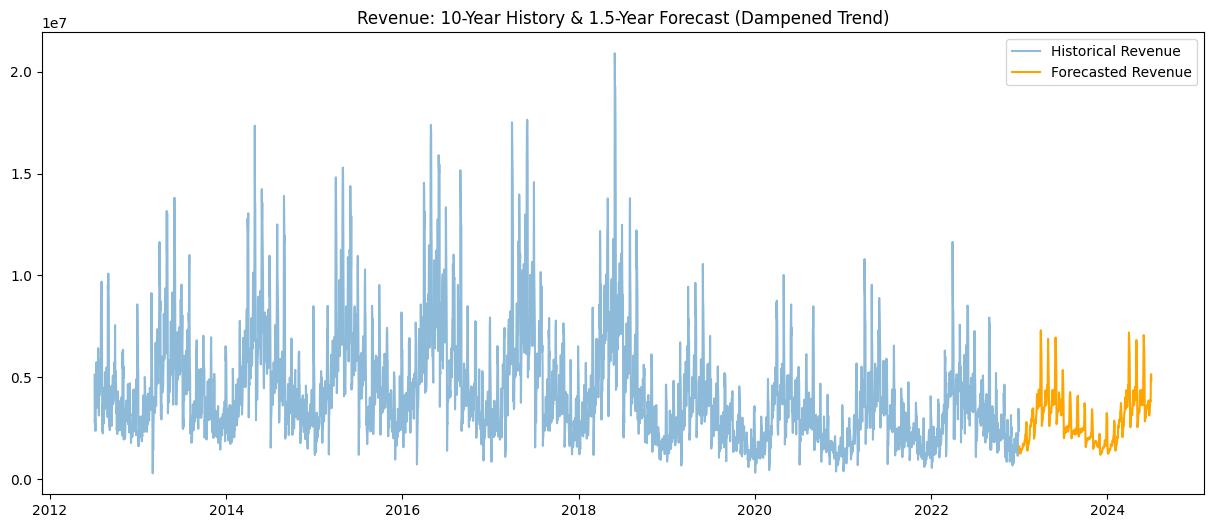

In [44]:
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Revenue'], label='Historical Revenue', alpha=0.5)
plt.plot(submission['Date'], submission['Revenue'], label='Forecasted Revenue', color='orange')
plt.title("Revenue: 10-Year History & 1.5-Year Forecast (Dampened Trend)")
plt.legend()
plt.show()